# Notebook 1 — From the task to the design matrix

*SWC ENC 2026 · behaviour module · based on Piet et al. (2024), Neuron*

You've read the paper, so here's the one-paragraph refresher. Head-fixed mice
watch a stream of natural images (250 ms on, 500 ms gray) and are rewarded for
**licking when the image changes**. A mouse could solve this several ways — by
**visually comparing** each image to the last, by **timing** how long since it
last acted, or just by licking a lot. Piet et al. capture all of these at once
with a single model of *when a licking bout starts*, built from five
**strategy regressors**. Everything in Figures 1–2 is built on that model.

**Vocabulary — image presentations.** The task advances in discrete steps: each
**image presentation** (we'll usually just say **image**, following the paper) is
a single **750 ms slot** — 250 ms with an image on screen, then 500 ms of gray. A
one-hour session is a sequence of about **4,800 image presentations**, and this is
the basic unit for everything that follows: one row of the design matrix per
image, and one yes/no question per image (*did a licking bout start on it?*). Most
images are ordinary repeats, but three kinds are special and do the real work in
the model:

* a **change image** — the picture differs from the previous one; this is what the
  mouse is rewarded for licking to;
* an **omitted image** — the image is withheld and the gray screen simply
  continues (5% of images, used as distractors);
* a **post-omission image** — the first ordinary image immediately after an
  omission.

**Today's goal (Notebooks 1–7):** understand *why* and *how* that model works by
fitting it to synthetic mice whose true strategy we know. We start at the very
bottom of the pipeline: turning raw licks and the stimulus stream into the
**design matrix** the model consumes.

**In this notebook you will:**
1. Segment a stream of licks into **bouts**.
2. Reduce each session to a per-image outcome: *did a bout start on this image?*
3. Build the five-column **design matrix** $X$ (Figure 1C).

---
**The paper panels this notebook reproduces**

<img src="../assets/paper/fig1a.png" width="460">

*Fig. 1A — the change-detection task. Mice watch a stream of images and are
rewarded for licking when the image changes; they might solve it by visually
comparing successive images or by learning the average time between changes.*

<img src="../assets/paper/fig1c.png" width="760">

*Fig. 1C — from raw licking to model inputs: how each image presentation becomes a
row of the five-strategy design matrix. Building that design matrix is this
notebook's goal.*

## Setup

`swcbehav` is the course backend: it generates synthetic mice and holds
reference implementations of everything you'll write. Select the
**"SWC Behaviour (.venv)"** kernel if the notebook asks.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import swcbehav as sb

## 1. Meet a session

We generate one synthetic mouse. For now treat `make_mouse` as a black box — we
open it up in Notebook 2. This mouse uses the **visual** strategy.

Each row of `sess.table` is one image. The **observable** columns are the
ones a real experiment would give you:

| column | meaning |
|---|---|
| `time` | onset of the image (s) |
| `is_change` | the image differs from the previous one |
| `is_omission` | the image was withheld (gray screen) |
| `is_post_omission` | first image after an omission |
| `bout_start` | a licking bout started on this image |

Columns beginning `true_` are **hidden ground truth** (the weights and lick
probability that generated the data). We'll peek at them only to check our work —
never as an input to analysis.

In [2]:
sess = sb.make_mouse("visual", seed=0)
print(f"{len(sess.table)} images, {len(sess.lick_times)} licks")
sess.table.head(8)

4800 images, 11151 licks


,image_index,time,image_id,is_change,is_omission,is_post_omission,bout_start,is_hit,is_miss,reward,true_p_lick,true_w_bias,true_w_visual,true_w_omission,true_w_post_omission,true_w_timing
0,0,0.00,6,False,False,False,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0
1,1,0.75,6,False,True,False,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0
2,2,1.50,6,False,False,True,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0
3,3,2.25,6,False,False,False,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0
4,4,3.00,6,False,False,False,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0
5,5,3.75,6,False,False,False,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0
6,6,4.50,5,True,False,False,True,True,False,True,0.880797,-3.0,5.0,0.0,0.0,0.0
7,7,5.25,5,False,False,False,False,False,False,False,0.047426,-3.0,5.0,0.0,0.0,0.0


Here are ~25 s of the session — your first look at the raw behavior:

- *Black ticks* are licks
- *Grey spans* are licking bouts
- *Solid blue lines* mark image changes
- *Dashed cyan lines* mark omissions (the image is withheld — a 5% distractor)
- *Red triangles* mark rewarded changes (hits)

Notice this mouse licks almost exclusively right after a change.

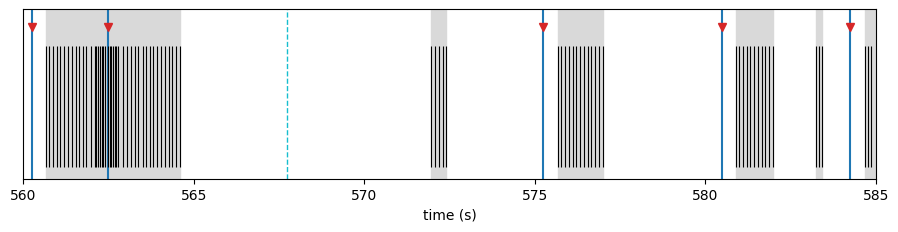

In [3]:
sb.plotting.plot_session_raster(sess, t0=560, t1=585)
plt.show()

## 2. From licks to bouts

Licking is bursty: the mouse emits a rapid train of licks, pauses, then bursts
again. The unit the model cares about is the **bout**, not the individual lick.
The standard rule (paper: Figure S2) is a threshold on the **inter-lick
interval**: a new bout begins whenever the gap since the previous lick exceeds
**700 ms**.

**Exercise 1.** Implement `segment_bouts`. Given a sorted array of lick times,
return an `(n_bouts, 2)` array of `[start_time, end_time]`.
*Hints:* `np.diff` gives the inter-lick intervals; `np.flatnonzero(gaps >
threshold)` finds the indices just before each break.

In [4]:
def segment_bouts(lick_times, threshold=0.7):
    lick_times = np.sort(np.asarray(lick_times))
    gaps = np.diff(lick_times)
    breaks = np.flatnonzero(gaps > threshold)     # last lick of each bout (except the last)
    starts = np.concatenate(([0], breaks + 1))
    ends = np.concatenate((breaks, [len(lick_times) - 1]))
    return np.column_stack((lick_times[starts], lick_times[ends]))

In [5]:
bouts = segment_bouts(sess.lick_times)
reference = sb.segment_bouts(sess.lick_times)
print(f"found {len(bouts)} bouts; matches the reference implementation: "
      f"{np.array_equal(bouts, reference)}")

found 697 bouts; matches the reference implementation: True


## 3. From bouts to a per-image outcome

The model predicts a **single binary outcome per image**: did a licking bout
*start* during this image's 750 ms window? That vector, $y$, is what we'll later
regress against the strategies.

**Exercise 2.** Fill in `bout_starts_per_image`: map each bout's *start time* to
the image whose window contains it.
*Hint:* image $i$ covers $[\,t_0 + i\cdot\Delta,\; t_0 + (i{+}1)\cdot\Delta\,)$
where $\Delta$ = `sb.IMAGE_DURATION`.

In [6]:
def bout_starts_per_image(sess, bouts):
    onset = sess.table["time"].to_numpy()
    y = np.zeros(len(onset), dtype=bool)
    idx = np.floor((bouts[:, 0] - onset[0]) / sb.IMAGE_DURATION).astype(int)
    idx = idx[(idx >= 0) & (idx < len(onset))]
    y[idx] = True
    return y

y = bout_starts_per_image(sess, bouts)

Because this is synthetic data we can check $y$ against the true `bout_start`
column. (With real data you'd never have this luxury — which is exactly why we
teach with synthetic data.) It won't be a perfect match: adjacent bouts sometimes
merge under the 700 ms rule. Getting ~97% agreement is expected and worth a
discussion about the limits of bout segmentation.

In [7]:
truth = sess.table["bout_start"].to_numpy()
print(f"agreement with ground-truth bout_start: {(y == truth).mean():.3f}")

agreement with ground-truth bout_start: 0.966


## 4. The timing regressor

Four of the five regressors are read straight off the stimulus. The **timing**
regressor is different: it encodes *how long the mouse has waited*. It is a
sigmoid of the number of images since the last bout — low right after a bout,
crossing 0.5 at four images, then saturating high:

$$\text{timing}(t) = \sigma\!\left(\frac{n_t - 4}{1}\right),\qquad
n_t = \text{images since the last bout start.}$$

This is the only regressor that depends on the animal's own past behavior.

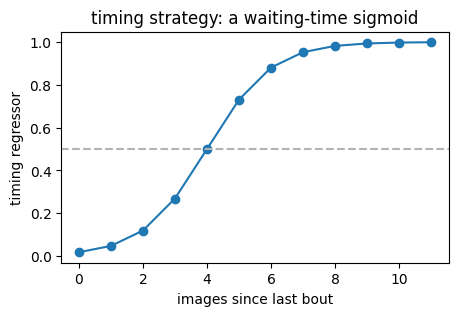

In [8]:
n = np.arange(0, 12)
plt.figure(figsize=(5, 3))
plt.plot(n, sb.timing_feature(n), "o-")
plt.axhline(0.5, color="0.7", ls="--")
plt.xlabel("images since last bout"); plt.ylabel("timing regressor")
plt.title("timing strategy: a waiting-time sigmoid")
plt.show()

## 5. Build the design matrix

Now assemble everything into the design matrix $X$ — one row per image, five
columns:

| column | value |
|---|---|
| `bias` | 1 everywhere (overall drive to lick) |
| `visual` | 1 on image changes |
| `omission` | 1 on omitted images |
| `post_omission` | 1 on the image after an omission |
| `timing` | the waiting-time sigmoid from §4 |

**Exercise 3 (the payoff).** Complete `build_design_matrix`. Use
`sb.images_since_bout(bout_start)` for the waiting-time counter and
`sb.timing_feature` for the sigmoid.

In [9]:
def build_design_matrix(sess, bout_start):
    since = sb.images_since_bout(bout_start)
    X = np.column_stack([
        np.ones(len(sess.table)),                                  # bias
        sess.table["is_change"].to_numpy().astype(float),          # visual
        sess.table["is_omission"].to_numpy().astype(float),        # omission
        sess.table["is_post_omission"].to_numpy().astype(float),   # post_omission
        sb.timing_feature(since),                                  # timing
    ])
    return X

col_names = ["bias", "visual", "omission", "post_omission", "timing"]
X = build_design_matrix(sess, y)
print("design matrix shape:", X.shape)

design matrix shape: (4800, 5)


Check it against the backend, then look at the design matrix **next to the
behavior it is meant to explain**. The bottom panel is the design matrix for a
window of images — the paper's Figure 1C — and the top panel is the same mouse's
licking over those very same images (annotated as before). Reading down each
column, you can see the regressors line up with what the mouse did:

- the **visual** row lights up on changes — exactly where this mouse licks;
- the **timing** row ramps up the longer it has been since the last bout;
- the **omission** and **post_omission** rows fire on the withheld images and the
  image immediately after.

(This window is chosen to contain omissions, so all five rows are active — the
model doesn't yet *know* which regressors matter; that's what fitting decides,
starting in Notebook 3.)

matches reference: True


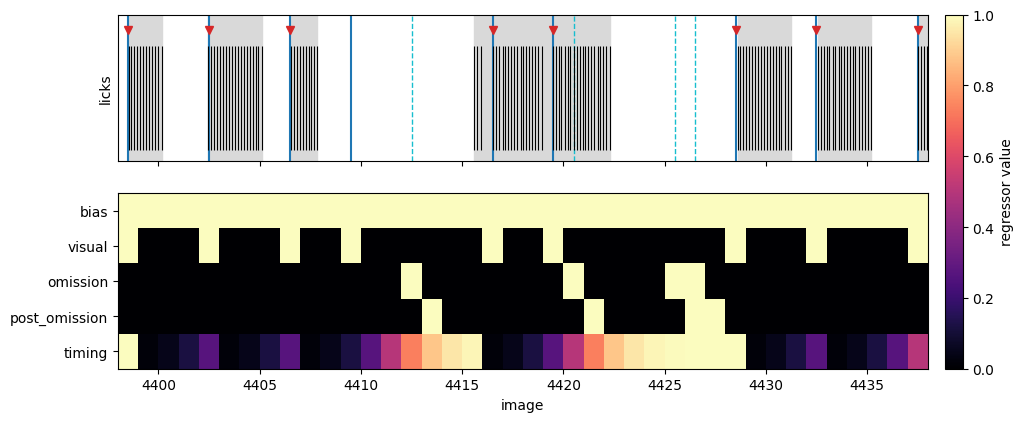

In [10]:
# Compare against the backend built from the SAME bout vector, so we're checking
# our construction logic -- not the small segmentation mismatch from Exercise 2.
X_ref, _ = sb.build_design_matrix(sess.table, bout_start=y)
print("matches reference:", np.allclose(X, X_ref))

sb.plotting.plot_regressors_and_licks(sess, X, col_names, start=4398, n=40)
plt.show()

## Wrap-up

You turned a raw lick stream into the exact object the strategy model consumes:
a per-image outcome $y$ and a design matrix $X$ whose columns are the five
candidate strategies. You also saw the one regressor (timing) that depends on the
animal's own history.

**Next (Notebook 2):** open up `make_mouse` and look at how *different*
strategies show up in behavior — a visual mouse, a timing mouse, and a mouse
whose strategy drifts — before we start fitting anything.